In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   - -------------------------------------- 1.8/69.5 MB 12.3 MB/s eta 0:00:06
   -- ------------------------------------- 4.7/69.5 MB 12.5 MB/s eta 0:00:06
   ---- ----------------------------------- 7.1/69.5 MB 12.6 MB/s eta 0:00:05
   ----- ---------------------------------- 9.7/69.5 MB 12.3 MB/s eta 0:00:05
   ------ --------------------------------- 11.3/69.5 MB 11.5 MB/s eta 0:00:06
   ------- -------------------------------- 13.1/69.5 MB 11.0 MB/s eta 0:00:06
   -------- ------------------------------- 15.2/69.5 MB 10.8 MB/s eta 0:00:06
   --------- ------------------------------ 17.0/69.5 MB 10.6 MB/s eta 0:00:05
   ----------- ---------------------------- 19.7/69.5 MB 10.7 MB/s eta 0:00:05
   ------------ --------------------------- 21.0/69.5 MB 10.4 MB/s eta 0:00:05
   ------------ --------------------------- 21.8/69.5 MB 9.6 MB/s eta 0:00

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
df = pd.read_csv('creditcard.csv')
print("Dataset loaded successfully!")
print(df.shape)

Dataset loaded successfully!
(284807, 31)


In [4]:
df.head()
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [5]:
print(df.shape)
df.info()

(284807, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 2

In [6]:
print(df.isnull().sum())
print(df.describe())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.175161e-15  3.384974e-16 -1.379537e-15  2.094852e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027

In [7]:
print(df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


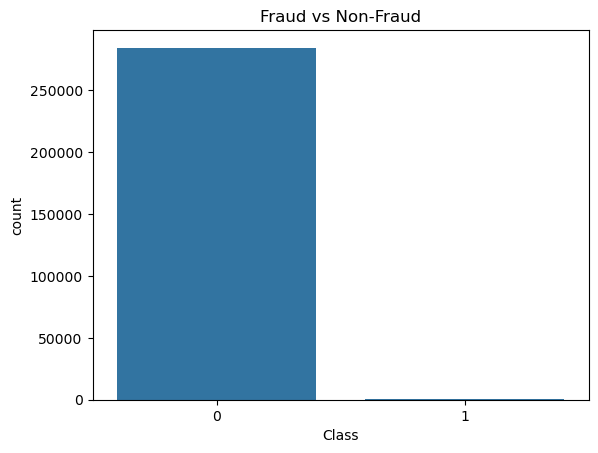

In [8]:
sns.countplot(x='Class', data=df)
plt.title('Fraud vs Non-Fraud')
plt.show()

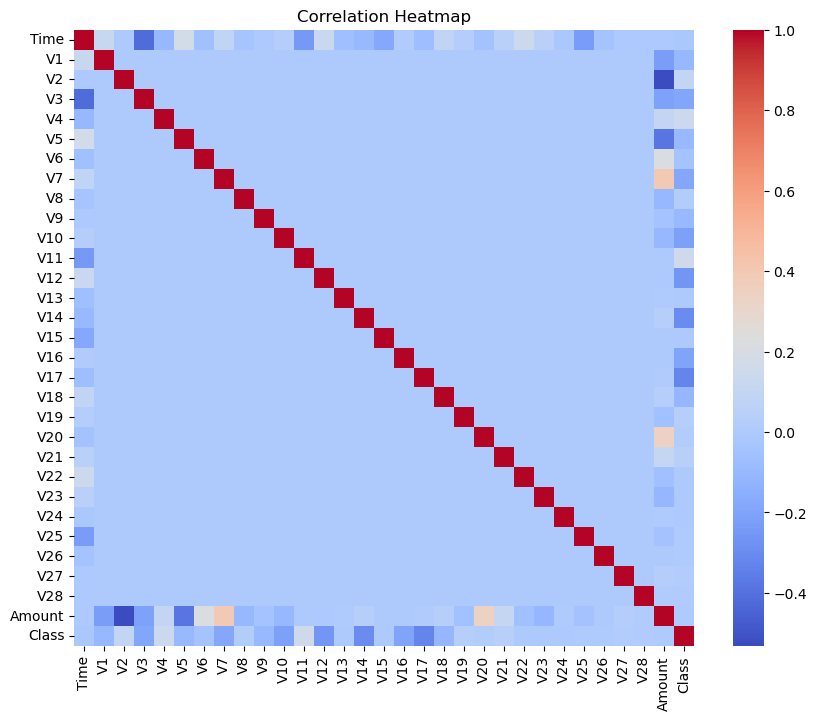

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [10]:
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])

In [11]:
X = df.drop('Class', axis=1)
y = df['Class']
print(X.shape, y.shape)

(284807, 30) (284807,)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(227845, 30) (56962, 30)


In [13]:
print("Before SMOTE:")
print(y_train.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64


In [14]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [15]:
print("After SMOTE:")
print(pd.Series(y_train_sm).value_counts())

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


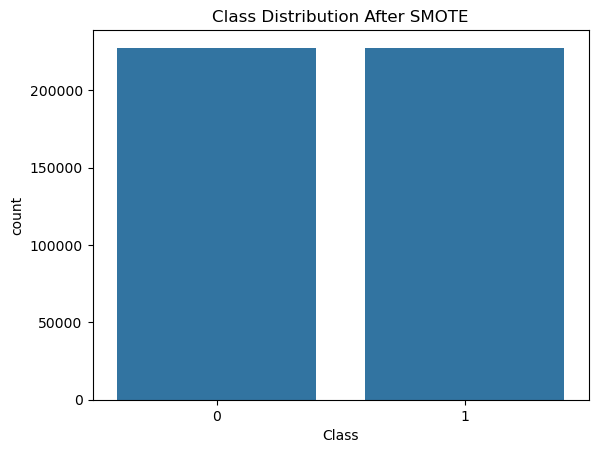

In [16]:
sns.countplot(x=y_train_sm)
plt.title('Class Distribution After SMOTE')
plt.show()

In [18]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train_sm, y_train_sm)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression Done!")

Logistic Regression Done!


In [19]:
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train_sm, y_train_sm)
y_pred_xgb = xgb.predict(X_test)
print("XGBoost Done!")

XGBoost Done!


In [20]:
iso = IsolationForest(contamination=0.002, random_state=42)
iso.fit(X_train_sm)
y_pred_iso = iso.predict(X_test)
y_pred_iso = [1 if x == -1 else 0 for x in y_pred_iso]
print("Isolation Forest Done!")

Isolation Forest Done!


In [21]:
print("Logistic Regression:")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_lr))

Logistic Regression:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC: 0.9463636115673055


In [22]:
print("XGBoost:")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_xgb))

XGBoost:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.68      0.86      0.76        98

    accuracy                           1.00     56962
   macro avg       0.84      0.93      0.88     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.928228505104912


In [23]:
print("Isolation Forest:")
print(classification_report(y_test, y_pred_iso))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_iso))

Isolation Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.00      0.00      0.00        98

    accuracy                           1.00     56962
   macro avg       0.50      0.50      0.50     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.49998241418120426


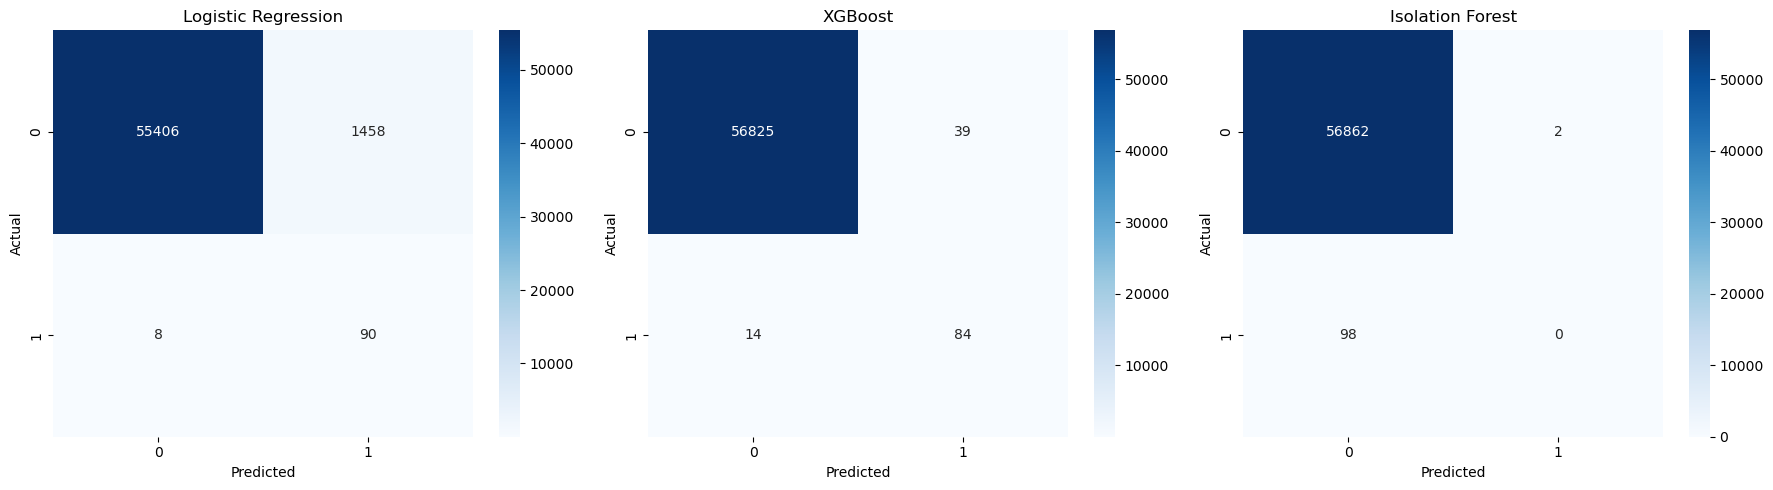

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = {'Logistic Regression': y_pred_lr, 'XGBoost': y_pred_xgb, 'Isolation Forest': y_pred_iso}

for ax, (name, preds) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues')
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

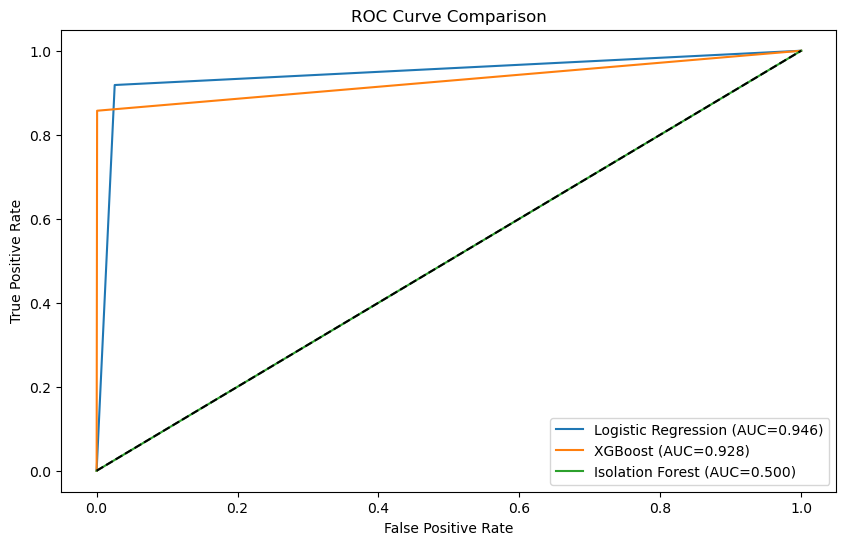

In [25]:
plt.figure(figsize=(10, 6))

for name, preds in models.items():
    fpr, tpr, _ = roc_curve(y_test, preds)
    auc = roc_auc_score(y_test, preds)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

In [26]:
!pip install streamlit

In [27]:
app_code = """
import streamlit as st
import pandas as pd
import numpy as np
import pickle
from sklearn.preprocessing import StandardScaler

model = pickle.load(open('xgb_model.pkl', 'rb'))
scaler = pickle.load(open('scaler.pkl', 'rb'))

st.title("Credit Card Fraud Detection")
st.write("Enter transaction details to predict fraud probability")

amount = st.number_input("Transaction Amount", min_value=0.0)
time = st.number_input("Time (seconds elapsed)", min_value=0.0)

st.write("Enter V1 to V28 features:")
v_features = []
cols = st.columns(4)
for i in range(1, 29):
    with cols[(i-1) % 4]:
        v_features.append(st.number_input(f"V{i}", value=0.0))

if st.button("Predict"):
    amount_scaled = scaler.transform([[amount]])[0][0]
    time_scaled = scaler.transform([[time]])[0][0]
    features = [time_scaled] + v_features + [amount_scaled]
    prediction = model.predict_proba([features])[0][1]
    
    if prediction > 0.5:
        st.error(f"Fraud Detected! Probability: {prediction:.2%}")
    else:
        st.success(f"Legitimate Transaction! Fraud Probability: {prediction:.2%}")
"""

with open('app.py', 'w') as f:
    f.write(app_code)

print("app.py created successfully!")

app.py created successfully!


In [28]:
import pickle

pickle.dump(xgb, open('xgb_model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))

print("Model & Scaler saved successfully!")

Model & Scaler saved successfully!


In [34]:
fraud_cases = df[df['Class'] == 1].head(3)
print(fraud_cases.to_string())

          Time        V1        V2        V3        V4        V5        V6        V7        V8        V9       V10       V11       V12       V13       V14       V15       V16       V17       V18       V19       V20       V21       V22       V23       V24       V25       V26       V27       V28    Amount  Class
541  -1.988034 -2.312227  1.951992 -1.609851  3.997906 -0.522188 -1.426545 -2.537387  1.391657 -2.770089 -2.772272  3.202033 -2.899907 -0.595222 -4.289254  0.389724 -1.140747 -2.830056 -0.016822  0.416956  0.126911  0.517232 -0.035049 -0.465211  0.320198  0.044519  0.177840  0.261145 -0.143276 -0.353229      1
623  -1.986644 -3.043541 -3.157307  1.088463  2.288644  1.359805 -1.064823  0.325574 -0.067794 -0.270953 -0.838587 -0.414575 -0.503141  0.676502 -1.692029  2.000635  0.666780  0.599717  1.725321  0.283345  2.102339  0.661696  0.435477  1.375966 -0.293803  0.279798 -0.145362 -0.252773  0.035764  1.761758      1
4920 -1.902623 -2.303350  1.759247 -0.359745  2.330243 -0.821628

In [33]:
fraud_cases = df[df['Class'] == 1].head(3)
print(fraud_cases[['Time', 'Amount', 'Class']])

          Time    Amount  Class
541  -1.988034 -0.353229      1
623  -1.986644  1.761758      1
4920 -1.902623  0.606031      1


In [41]:
app_code = """
import streamlit as st
import numpy as np
import pickle

model = pickle.load(open('xgb_model.pkl', 'rb'))

fraud_sample = {
    'Time': -1.988034,
    'V1': -1.988034, 'V2': -2.312227, 'V3': 1.951992, 'V4': -1.609851,
    'V5': 3.997906, 'V6': -0.522188, 'V7': -1.426545, 'V8': -2.537387,
    'V9': 1.391657, 'V10': -2.770089, 'V11': -2.772272, 'V12': 3.202033,
    'V13': -2.899907, 'V14': -0.595222, 'V15': -4.289254, 'V16': 0.389724,
    'V17': -1.140747, 'V18': -2.830056, 'V19': -0.016822, 'V20': 0.416956,
    'V21': 0.126911, 'V22': 0.517232, 'V23': -0.035049, 'V24': -0.465211,
    'V25': 0.320198, 'V26': 0.044519, 'V27': 0.177840, 'V28': 0.261145,
    'Amount': -0.353229
}

st.title("Credit Card Fraud Detection")

if st.button("Load Sample Fraud Case"):
    st.session_state.load_fraud = True

load = st.session_state.get('load_fraud', False)

time = st.number_input("Time", value=fraud_sample['Time'] if load else 0.0, format="%.6f", step=0.000001)
amount = st.number_input("Amount", value=fraud_sample['Amount'] if load else 0.0, format="%.6f", step=0.000001)

st.write("Enter V1 to V28 features:")
v_features = []
cols = st.columns(4)
for i in range(1, 29):
    with cols[(i-1) % 4]:
        v_features.append(st.number_input(f"V{i}", value=fraud_sample[f'V{i}'] if load else 0.0, format="%.6f", step=0.000001))

if st.button("Predict"):
    features = [time] + v_features + [amount]
    prediction = model.predict_proba([features])[0][1]
    if prediction > 0.5:
        st.error(f"Fraud Detected! Probability: {prediction:.2%}")
    else:
        st.success(f"Legitimate Transaction! Fraud Probability: {prediction:.2%}")
"""

with open('app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

print("app.py updated!")

app.py updated!


In [39]:
fraud_cases = df[df['Class'] == 1].head(1)
feature_values = fraud_cases.drop('Class', axis=1).values[0]
print("Features:", feature_values)
print("Length:", len(feature_values))

import pickle
model = pickle.load(open('xgb_model.pkl', 'rb'))
prediction = model.predict_proba([feature_values])[0][1]
print("Fraud Probability:", prediction)

Features: [-1.98803351 -2.31222654  1.95199201 -1.60985073  3.99790559 -0.52218786
 -1.42654532 -2.53738731  1.39165725 -2.77008928 -2.77227214  3.20203321
 -2.89990739 -0.59522188 -4.28925378  0.38972412 -1.14074718 -2.83005567
 -0.01682247  0.41695571  0.12691056  0.51723237 -0.03504937 -0.46521108
  0.3201982   0.04451917  0.1778398   0.261145   -0.14327587 -0.35322939]
Length: 30
Fraud Probability: 0.999278


In [40]:
print(df.columns.tolist())

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [42]:
import pickle
import numpy as np

model = pickle.load(open('xgb_model.pkl', 'rb'))

fraud_cases = df[df['Class'] == 1].head(1)
X_fraud = fraud_cases.drop('Class', axis=1).values[0]

prediction = model.predict_proba([X_fraud])[0][1]
print(f"Fraud Probability: {prediction:.2%}")

Fraud Probability: 99.93%


In [46]:
fraud_cases = df[df['Class'] == 1]
legit_cases = df[df['Class'] == 0].sample(n=5000, random_state=42)
small_df = pd.concat([fraud_cases, legit_cases])
small_df.to_csv('creditcard_small.csv', index=False)
print("Small dataset created!", small_df.shape)

Small dataset created! (5492, 31)


In [47]:
app_code = """
import streamlit as st
import numpy as np
import pickle
import pandas as pd
from sklearn.preprocessing import StandardScaler

model = pickle.load(open('xgb_model.pkl', 'rb'))

df = pd.read_csv('creditcard_small.csv')
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])

fraud_sample = df[df['Class'] == 1].drop('Class', axis=1).iloc[0].tolist()

st.title("Credit Card Fraud Detection")
st.write("Enter transaction details to predict fraud probability")

if 'input_data' not in st.session_state:
    st.session_state.input_data = [0.0] * 30

if st.button("Load Sample Fraud Case"):
    st.session_state.input_data = fraud_sample

time = st.number_input("Time", value=float(st.session_state.input_data[0]), format="%.6f", step=0.000001)
v_features = []
cols = st.columns(4)
for i in range(1, 29):
    with cols[(i-1) % 4]:
        v_features.append(st.number_input(f"V{i}", value=float(st.session_state.input_data[i]), format="%.6f", step=0.000001))
amount = st.number_input("Amount", value=float(st.session_state.input_data[29]), format="%.6f", step=0.000001)

if st.button("Predict"):
    features = [time] + v_features + [amount]
    prediction = model.predict_proba([features])[0][1]
    if prediction > 0.5:
        st.error(f"Fraud Detected! Probability: {prediction:.2%}")
    else:
        st.success(f"Legitimate Transaction! Fraud Probability: {prediction:.2%}")
"""

with open('app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

print("app.py updated!")

app.py updated!


In [48]:
with open('requirements.txt', 'w') as f:
    f.write("streamlit\nnumpy\npandas\nscikit-learn\nxgboost\n")
print("requirements.txt created!")

requirements.txt created!
